# ArtBench-10 Student Starter Pack

This notebook is a starting template for class projects using **ArtBench-10**.

It covers:

1. Loading ArtBench-10 from the local folder `artbench_generative_suite/ArtBench-10`
2. Exploring dataset shape and class distribution
3. Building PyTorch dataloaders
4. Visualizing samples in a grid
5. Exporting samples to image files (one image per file)
6. Loading subset definitions from `training.csv` generated by `generate_training_csv.py`


## Dataset quick notes

- **Domain**: paintings / artistic styles
- **Classes**: 10 styles
- **Image size**: 32x32 RGB
- **Splits**: train and test

In this project setup, dataset files are expected in:

- `ArtBench-10/artbench-10-python/artbench-10-batches-py/`
- `ArtBench-10/ArtBench-10.csv`

If you do not have it on the folder, download from kaggle directly:

https://www.kaggle.com/datasets/alexanderliao/artbench10


In [1]:
from __future__ import annotations

import sys
import random
from pathlib import Path
from collections import Counter

import numpy as np
from datetime import datetime
import gc
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from torchvision.utils import make_grid, save_image
import matplotlib.pyplot as plt
import json
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from tqdm.auto import tqdm
from torchvision.models import Inception_V3_Weights, inception_v3
from scipy import linalg

c:\Users\ASUSR7\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Define reproducibility and device selection (`cuda`, `mps`, `cpu`).

In [2]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

def get_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    if torch.backends.mps.is_available() and torch.backends.mps.is_built():
        return torch.device('mps')
    return torch.device('cpu')

device = get_device()
print('Device:', device)

Device: cpu


In [3]:
# Relative paths (run this notebook from student_start_pack/)
PROJECT_ROOT = Path('..')
SCRIPTS_DIR = PROJECT_ROOT / 'scripts'
KAGGLE_ROOT = PROJECT_ROOT

if not KAGGLE_ROOT.exists() or not (SCRIPTS_DIR / 'artbench_local_dataset.py').exists():
    raise FileNotFoundError(
        'Could not resolve project folders from relative paths. '
        'Run this notebook from student_start_pack/ or adjust PROJECT_ROOT.'
    )

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

print('PROJECT_ROOT =', PROJECT_ROOT)
print('KAGGLE_ROOT  =', KAGGLE_ROOT)

PROJECT_ROOT = ..
KAGGLE_ROOT  = ..


In [4]:
# Uses your existing project helper to load ArtBench-10 from local Kaggle-style files
from artbench_local_dataset import load_kaggle_artbench10_splits

hf_ds = load_kaggle_artbench10_splits(KAGGLE_ROOT)
train_hf = hf_ds["train"]

print("Train size:", len(train_hf))
print("Columns   :", train_hf.column_names)

label_feature = train_hf.features["label"]
class_names = list(label_feature.names)
num_classes = len(class_names)
print("Num classes:", num_classes)
print("Class names:", class_names)

Dataset source: kaggle root='..'
Train size: 50000
Columns   : ['image', 'label']
Num classes: 10
Class names: ['impressionism', 'realism', 'romanticism', 'expressionism', 'baroque', 'post_impressionism', 'art_nouveau', 'surrealism', 'ukiyo_e', 'renaissance']


In [5]:
# Class distribution summary
train_counts = Counter(train_hf["label"])

print("\nTrain class distribution:")
for cid, name in enumerate(class_names):
    print(f"  {cid:2d} | {name:>15s} | {train_counts.get(cid, 0):6d}")


Train class distribution:
   0 |   impressionism |   5000
   1 |         realism |   5000
   2 |     romanticism |   5000
   3 |   expressionism |   5000
   4 |         baroque |   5000
   5 | post_impressionism |   5000
   6 |     art_nouveau |   5000
   7 |      surrealism |   5000
   8 |         ukiyo_e |   5000
   9 |     renaissance |   5000


## Build PyTorch datasets and dataloaders

You can change:

- `IMAGE_SIZE` (default 32)
- `BATCH_SIZE`
- `TRAIN_FRACTION` if you want to train on a subset

In [6]:
IMAGE_SIZE = 32
BATCH_SIZE = 64
NUM_WORKERS = 2

def safe_num_workers(requested: int) -> int:
    # Avoid notebook multiprocessing pickling issues on macOS/ipykernel.
    if "ipykernel" in sys.modules and int(requested) > 0:
        print("Notebook kernel detected: forcing num_workers=0 for DataLoader stability.")
        return 0
    return int(requested)

EFFECTIVE_NUM_WORKERS = safe_num_workers(NUM_WORKERS)
TRAIN_FRACTION = 1.0  # Example: 0.5 means half of train split

transform = T.Compose([
    T.Resize(IMAGE_SIZE, interpolation=T.InterpolationMode.BILINEAR),
    T.CenterCrop(IMAGE_SIZE),
    T.ToTensor(),  # outputs [0,1]
    T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])


class HFDatasetTorch(Dataset):
    def __init__(self, hf_split, transform=None, indices=None):
        self.ds = hf_split
        self.transform = transform
        self.indices = list(range(len(hf_split))) if indices is None else list(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        ex = self.ds[real_idx]
        img = ex["image"]
        y = int(ex["label"])
        x = self.transform(img) if self.transform else img
        return x, y, real_idx


def make_subset_indices(n_total: int, fraction: float, seed: int = 42):
    n_keep = max(1, int(round(n_total * fraction)))
    g = np.random.RandomState(seed)
    idx = np.arange(n_total)
    g.shuffle(idx)
    return idx[:n_keep].tolist()


train_indices = make_subset_indices(len(train_hf), TRAIN_FRACTION, seed=SEED)

train_ds = HFDatasetTorch(train_hf, transform=transform, indices=train_indices)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print("Train dataset length (after fraction):", len(train_ds))
print("Train batches                        :", len(train_loader))

Notebook kernel detected: forcing num_workers=0 for DataLoader stability.
Train dataset length (after fraction): 50000
Train batches                        : 782


## Load subset of 20% samples `training_20_percent.csv` 

you can reproduce the same subset in this notebook by loading IDs from that CSV.

Use `train_id_original` for indexing this notebook's full train split.


In [7]:
import csv

#warning if using colab kernel on vscode you need to put the files on your google drive and link this notebook to it.
TRAINING_CSV_PATH = Path('training_20_percent.csv')
INDEX_COLUMN = 'train_id_original'  # recommended 


def load_ids_from_training_csv(csv_path: Path, index_column: str = "train_id_original") -> list[int]:
    csv_path = Path(csv_path)
    if not csv_path.exists():
        raise FileNotFoundError(
            f"training.csv not found: {csv_path}\n"
            "Generate it first with scripts/generate_training_csv.py"
        )

    ids = []
    with open(csv_path, 'r', encoding='utf-8', newline='') as f:
        r = csv.DictReader(f)
        if index_column not in (r.fieldnames or []):
            raise ValueError(
                f"Column {index_column!r} not present in {csv_path}. "
                f"Available: {r.fieldnames}"
            )
        for row in r:
            v = str(row.get(index_column, "")).strip()
            if v == "":
                continue
            ids.append(int(v))

    if len(ids) == 0:
        raise ValueError(f"No ids found in {csv_path} column {index_column!r}")
    return ids


train_ids_from_csv = load_ids_from_training_csv(TRAINING_CSV_PATH, index_column=INDEX_COLUMN)
print('Loaded ids:', len(train_ids_from_csv))
print('First 10 ids:', train_ids_from_csv[:10])

# Build a train dataset/loader using exactly those IDs
train_ds_from_csv = HFDatasetTorch(train_hf, transform=transform, indices=train_ids_from_csv)
train_loader_from_csv = DataLoader(
    train_ds_from_csv,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print('Subset train dataset length:', len(train_ds_from_csv))
print('Subset train batches      :', len(train_loader_from_csv))


#Test Loader
all_train_indices = set(range(len(train_hf)))

# Índices que não estão no CSV (restantes 80%)
test_indices = list(all_train_indices - set(train_ids_from_csv))

# Criar dataset de teste
test_ds_from_csv = HFDatasetTorch(train_hf, transform=transform, indices=test_indices)

# Criar DataLoader de teste
test_loader_from_csv = DataLoader(
    test_ds_from_csv,
    batch_size=BATCH_SIZE,
    shuffle=False,  # shuffle=False para avaliação
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("Test dataset length :", len(test_ds_from_csv))
print("Test batches        :", len(test_loader_from_csv))





Loaded ids: 10000
First 10 ids: [33553, 9427, 199, 12447, 39489, 42724, 10822, 49498, 4144, 36958]
Subset train dataset length: 10000
Subset train batches      : 157
Test dataset length : 40000
Test batches        : 625


## Visualize a sample grid

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


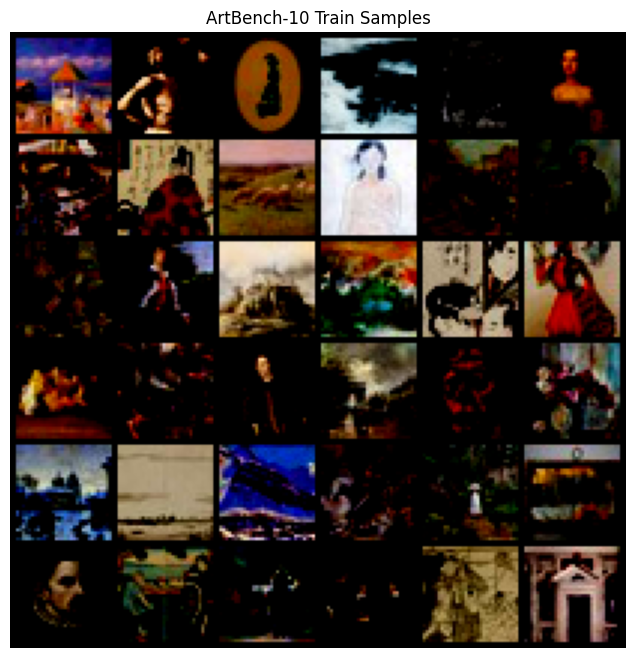

Labels: ['impressionism', 'renaissance', 'surrealism', 'realism', 'surrealism', 'baroque', 'surrealism', 'ukiyo_e', 'realism', 'post_impressionism', 'expressionism', 'impressionism', 'art_nouveau', 'impressionism', 'surrealism', 'expressionism', 'ukiyo_e', 'art_nouveau', 'realism', 'baroque', 'baroque', 'impressionism', 'expressionism', 'post_impressionism', 'post_impressionism', 'ukiyo_e', 'art_nouveau', 'baroque', 'realism', 'surrealism', 'renaissance', 'ukiyo_e', 'expressionism', 'baroque', 'ukiyo_e', 'renaissance']


In [8]:
def show_batch_grid(loader, class_names, n_images=36, nrow=6, title='Sample Grid'):
    x, y, idx = next(iter(loader))
    x = x[:n_images]
    y = y[:n_images]

    grid = make_grid(x, nrow=nrow, padding=2)
    np_img = grid.permute(1, 2, 0).cpu().numpy()

    plt.figure(figsize=(8, 8))
    plt.imshow(np_img)
    plt.axis('off')
    plt.title(title)
    plt.show()

    # Print labels for quick inspection
    labels_str = [class_names[int(v)] for v in y]
    print('Labels:', labels_str)


show_batch_grid(train_loader, class_names, n_images=36, nrow=6, title='ArtBench-10 Train Samples')

## Export samples to image files

This helper saves one PNG per sample and writes a CSV with metadata.
Useful for qualitative analysis or external metric tools.

In [9]:
import csv


def export_split_to_folder(
    loader: DataLoader,
    class_names: list[str],
    out_dir: Path,
    max_images: int | None = 500,
):
    out_dir = Path(out_dir)
    img_dir = out_dir / 'images'
    img_dir.mkdir(parents=True, exist_ok=True)

    rows = []
    saved = 0

    for x, y, idx in loader:
        b = x.shape[0]
        for i in range(b):
            if max_images is not None and saved >= max_images:
                break

            label_id = int(y[i].item())
            label_name = class_names[label_id]
            src_idx = int(idx[i].item())

            file_name = f"img_{saved:06d}_label{label_id:02d}_idx{src_idx:06d}.png"
            path = img_dir / file_name
            save_image(x[i], path)

            rows.append({
                'file_name': file_name,
                'label_id': label_id,
                'label_name': label_name,
                'source_index': src_idx,
            })
            saved += 1

        if max_images is not None and saved >= max_images:
            break

    csv_path = out_dir / 'metadata.csv'
    with open(csv_path, 'w', encoding='utf-8', newline='') as f:
        w = csv.DictWriter(f, fieldnames=['file_name', 'label_id', 'label_name', 'source_index'])
        w.writeheader()
        w.writerows(rows)

    print(f'Exported {saved} images to: {img_dir}')
    print(f'Metadata CSV: {csv_path}')


EXPORT_ROOT = Path('exported_data')
EXPORT_ROOT.mkdir(parents=True, exist_ok=True)

export_split_to_folder(train_loader, class_names, EXPORT_ROOT / 'train_subset', max_images=500)


Exported 500 images to: exported_data\train_subset\images
Metadata CSV: exported_data\train_subset\metadata.csv


In [10]:
MODEL_DIR = Path('artifacts/models')
HISTORY_DIR = Path('artifacts/histories')
MODEL_DIR.mkdir(parents=True, exist_ok=True)
HISTORY_DIR.mkdir(parents=True, exist_ok=True)


USE_SAVED_MODELS_IF_AVAILABLE = True # Set to False to force retraining


def _artifact_stem(run_name):
    stem = ''.join(ch.lower() if ch.isalnum() else '_' for ch in run_name)
    stem = '_'.join(part for part in stem.split('_') if part)
    return stem or 'model'


def _artifact_paths(run_name):
    stem = _artifact_stem(run_name)
    return MODEL_DIR / f'{stem}.pt', HISTORY_DIR / f'{stem}.json'

def fit_or_load_model(model, run_name, train_fn, load_if_available=USE_SAVED_MODELS_IF_AVAILABLE, **train_kwargs):
    model_path, history_path = _artifact_paths(run_name)

    if load_if_available and model_path.exists():
        state_dict = torch.load(model_path, map_location=device)
        model.load_state_dict(state_dict)
        model.to(device)
        if history_path.exists():
            with history_path.open('r', encoding='utf-8') as f:
                history = json.load(f)
        else:
            history = []
        print(f'Loaded {run_name} model from {model_path}')
        return history

    history = train_fn(model=model, **train_kwargs)
    with model_path.open('wb') as f:
        torch.save(model.state_dict(), f)
    with history_path.open('w', encoding='utf-8') as f:
        json.dump(history, f, indent=2)
    print(f'Saved {run_name} model to {model_path} and history to {history_path}')
    return history

In [11]:
def show_reconstructions(model, loader, flatten_input, title='Recon', n_show=8):
    model.eval()
    x, _ = next(iter(loader))
    x = x.to(device)
    xin = x.view(x.size(0), -1) if flatten_input else x
    with torch.no_grad():
        xhat = model(xin)
    if flatten_input:
        xhat = xhat.view(-1, 1, 28, 28)

    x = x[:n_show].cpu().numpy()
    xhat = xhat[:n_show].cpu().numpy()

    fig, axes = plt.subplots(2, n_show, figsize=(1.5*n_show, 3.2))
    for i in range(n_show):
        axes[0, i].imshow(x[i, 0], cmap='gray')
        axes[1, i].imshow(xhat[i, 0], cmap='gray')
        axes[0, i].axis('off')
        axes[1, i].axis('off')
    axes[0, 0].set_ylabel('real')
    axes[1, 0].set_ylabel('recon')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


def show_reconstructions_vae(model, loader, title='VAE recon', n_show=8):
    model.eval()
    x, _ , _ = next(iter(loader))
    x = x.to(device)

    with torch.no_grad():
        xhat, _, _ = model(x)

    if x.dim() == 2:
        x = x.view(-1, 1, 28, 28)
    if xhat.dim() == 2:
        xhat = xhat.view(-1, 1, 28, 28)

    # Desnormalizar [-1,1] -> [0,1]
    x = (x[:n_show] * 0.5 + 0.5).cpu()
    xhat = (xhat[:n_show] * 0.5 + 0.5).cpu()

    fig, axes = plt.subplots(2, n_show, figsize=(1.5*n_show, 3.2))
    for i in range(n_show):
        axes[0, i].imshow(x[i].permute(1,2,0).numpy())
        axes[1, i].imshow(xhat[i].permute(1,2,0).numpy())
        axes[0, i].axis('off')
        axes[1, i].axis('off')
    axes[0, 0].set_ylabel('real')
    axes[1, 0].set_ylabel('recon')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


def plot_epoch_metric(histories, metric_key, title, ylabel):
    plt.figure(figsize=(5.0, 3.5))
    for name, hist in histories.items():
        plt.plot(range(1, len(hist)+1), [h[metric_key] for h in hist], marker='o', label=name)
    plt.xlabel('Epoch')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def report_autoencoder_metrics(name, history, metrics):
    print(f"[{name}] final train recon BCE: {history[-1]['train_recon_bce']:.4f}")
    print(f"[{name}] test metrics: {metrics}")


def report_vae_metrics(name, history, metrics):
    h = history[-1]
    print(f"[{name}] final train total: {h['train_loss']:.4f}")
    print(f"[{name}] final train recon: {h['train_recon_bce']:.4f}")
    print(f"[{name}] final train KL: {h['train_kl']:.4f}")
    print(f"[{name}] test metrics: {metrics}")


## 1 - Convolutional VAE

In [12]:
class ConvVAE(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()
        self.latent_dim = latent_dim

        # Encoder: 32x32 -> 16x16 -> 8x8 -> 4x4
        self.enc_conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
        )

        # TODO START
        # Add mean and log-variance heads from flattened conv features.
        conv_output_size = 128 * 4 * 4
        self.fc_mu = nn.Linear(conv_output_size, latent_dim)
        self.fc_logvar = nn.Linear(conv_output_size, latent_dim)
        # TODO END

        # Decoder: 4x4 -> 8x8 -> 16x16 -> 32x32
        self.dec_fc = nn.Linear(latent_dim, 128 * 4 * 4)
        self.dec_conv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, stride=2, padding=1),
            nn.Tanh(),  #normalização [-1, 1]
        )

    def encode(self, x):
        h = self.enc_conv(x)
        h = h.view(h.size(0), -1)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        # TODO START
        # Reparameterization trick: sample epsilon from N(0,1) and compute z = mu + epsilon * sigma
        std = torch.exp(0.5 * logvar)  # compute standard deviation
        eps = torch.randn_like(std)  # sample epsilon
        z = mu + eps * std  # compute z
        return z
        # TODO END

    def decode(self, z):
        h = self.dec_fc(z).view(-1, 128, 4, 4)
        return self.dec_conv(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        xhat = self.decode(z)
        return xhat, mu, logvar


In [13]:
def vae_loss(xhat, x, mu, logvar, beta=0.7):
    # TODO START
  
    recon = F.mse_loss(xhat, x, reduction='sum') / x.size(0)  # average per batch

    # KL divergence loss
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)

    # Total VAE loss
    loss = recon + beta * kl
    return loss, recon, kl
    # TODO END


def train_vae(model, loader, optimizer, epochs=20, beta=0.7):
    model.train()
    hist = []
    for ep in range(epochs):
        tl, tr, tk = 0.0, 0.0, 0.0
        for x, _ , _ , in tqdm(loader, leave=False):
            x = x.to(device)
            
            # TODO START
            optimizer.zero_grad()  # reset gradients
            xhat, mu, logvar = model(x)  # forward pass
            loss, recon, kl = vae_loss(xhat, x, mu, logvar, beta=beta)  # compute VAE loss
            loss.backward()  # compute gradients
            optimizer.step()  # update weights
            # TODO END
            
            tl += loss.item() * x.size(0)
            tr += recon.item() * x.size(0)
            tk += kl.item() * x.size(0)
        n = len(loader.dataset)
        hist.append({'train_loss': tl/n, 'train_recon_bce': tr/n, 'train_kl': tk/n})
        print(f'Epoch {ep+1}/{epochs} | train_loss={tl/n:.4f} train_recon={tr/n:.4f} train_kl={tk/n:.4f}')
    return hist


def evaluate_vae(model, loader, beta=0.7):
    model.eval()
    tl, tr, tk, tm, ta, n = 0.0, 0.0, 0.0, 0.0, 0.0, 0
    with torch.no_grad():
        for x, _ , _ in loader:
            x = x.to(device)
            xhat, mu, logvar = model(x)
            b = x.size(0)
            loss, recon, kl = vae_loss(xhat, x, mu, logvar, beta=beta)
            
            # TODO START
            tl += loss.item() * b
            tr += recon.item() * b
            tk += kl.item() * b
            tm += F.mse_loss(xhat, x, reduction='sum').item()
            ta += F.l1_loss(xhat, x, reduction='sum').item()
            n += b
            # TODO END

    numel = x[0].numel()
    return {'loss': tl/n, 'recon_bce': tr/n, 'kl': tk/n, 'mse': tm/(n*numel), 'mae': ta/(n*numel)}


In [14]:
vae = ConvVAE(latent_dim=128).to(device)
opt_vae = torch.optim.Adam(vae.parameters(), lr=1e-3)
EPOCHS_VAE = 100
BETA_VAE = 0.5
# TODO END
hist_vae = fit_or_load_model(
    model=vae,
    run_name='artbench_conv_vae',
    train_fn=train_vae,
    load_if_available=USE_SAVED_MODELS_IF_AVAILABLE,
    loader=train_loader_from_csv,   # train loader do subset 20%
    optimizer=opt_vae,
    epochs=EPOCHS_VAE,
    beta=BETA_VAE,
)
metrics_vae = evaluate_vae(vae, test_loader_from_csv, beta=BETA_VAE)

Loaded artbench_conv_vae model from artifacts\models\artbench_conv_vae.pt


[ArtBench VAE] final train total: 137.4997
[ArtBench VAE] final train recon: 92.6835
[ArtBench VAE] final train KL: 89.6325
[ArtBench VAE] test metrics: {'loss': 148.8787503417969, 'recon_bce': 103.0026177368164, 'kl': 91.75226555175782, 'mse': 0.033529497961203254, 'mae': 0.13414644784927368}


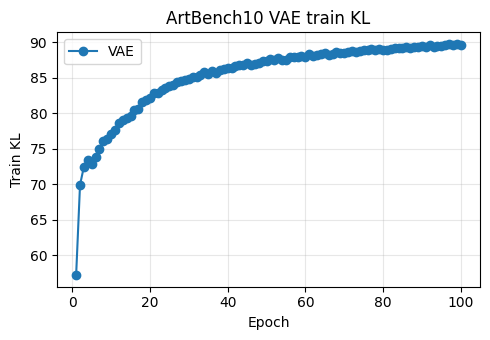

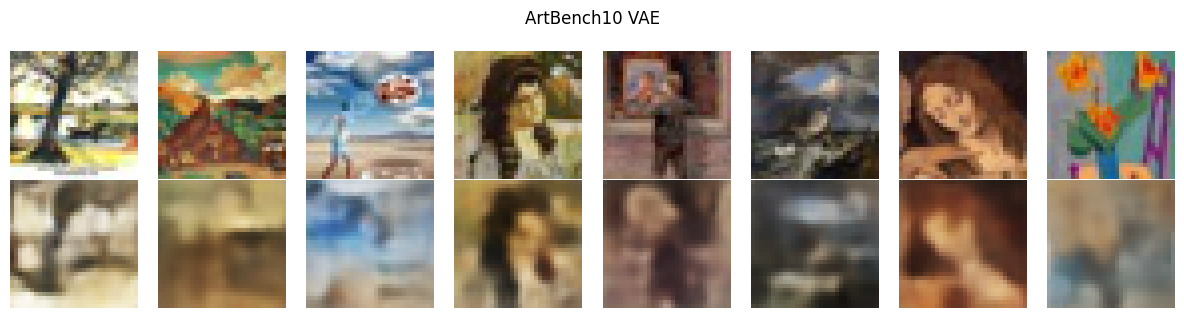

In [15]:
report_vae_metrics('ArtBench VAE', hist_vae, metrics_vae)

#plot_epoch_metric(
#    {'Dense AE': hist_dense_all, 'Convolutional AE': hist_conv_all, 'VAE (recon)': hist_vae_all},
#    'train_recon_bce',
#    'MNIST: train reconstruction BCE (3 models)',
#    'Train recon BCE'
#)
plot_epoch_metric({'VAE': hist_vae}, 'train_kl', 'ArtBench10 VAE train KL', 'Train KL')
show_reconstructions_vae(vae, test_loader_from_csv, title='ArtBench10 VAE')

#print('=== ArtBench10 comparison ===')
#print('Dense AE:', metrics_dense_all)
#print('Convolutional AE:', metrics_conv_all)
#print('VAE:', metrics_vae_all)

## 2 - DCGAN

Visual helper: display image grids.

In [16]:
def denorm(x):
    return (x + 1.0) / 2.0


def show_image_grid(images, channels, title='Images', n_show=25):
    images = images[:n_show].detach().cpu()
    images = denorm(images).clamp(0, 1)

    n = images.size(0)
    grid = int(np.ceil(np.sqrt(n)))
    fig, axes = plt.subplots(grid, grid, figsize=(grid * 1.6, grid * 1.6))
    axes = np.atleast_2d(axes)

    idx = 0
    for i in range(grid):
        for j in range(grid):
            ax = axes[i, j]
            ax.axis('off')
            if idx < n:
                if channels == 1:
                    ax.imshow(images[idx, 0], cmap='gray', vmin=0, vmax=1)
                else:
                    ax.imshow(images[idx].permute(1, 2, 0))
            idx += 1

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

In [17]:
class DCGenerator(nn.Module):
    def __init__(self, latent_dim=128, image_channels=3, ngf=64):
        super().__init__()
        self.latent_dim = latent_dim
        self.net = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, ngf * 4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf, image_channels, 4, 2, 1, bias=False),
            nn.Tanh(),
        )

    def forward(self, z):
        z = z.view(z.size(0), self.latent_dim, 1, 1)
        return self.net(z)


class DCDiscriminator(nn.Module):
    def __init__(self, image_channels=3, ndf=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(image_channels, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 4, 1, 4, 1, 0, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x).view(-1, 1)


def init_dcgan_weights(m):
    classname = m.__class__.__name__
    if 'Conv' in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

def plot_gan_losses(history, title='GAN losses'):
    plt.figure(figsize=(7, 4))
    plt.plot(history['d_loss'], label='Discriminator loss')
    plt.plot(history['g_loss'], label='Generator loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


def save_checkpoint(generator, discriminator, history, checkpoint_path, latent_dim, channels, image_size):
    checkpoint_path = Path(checkpoint_path)
    checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(
        {
            'generator': generator.state_dict(),
            'discriminator': discriminator.state_dict(),
            'history': history,
            'config': {
                'latent_dim': latent_dim,
                'channels': channels,
                'image_size': image_size,
            },
        },
        checkpoint_path,
    )
    print('Saved checkpoint to', checkpoint_path)


@torch.no_grad()
def load_dcgan_generator_for_inference(checkpoint_path):
    ckpt = torch.load(checkpoint_path, map_location=device)
    cfg = ckpt['config']
    generator = DCGenerator(latent_dim=cfg['latent_dim'], image_channels=cfg['channels']).to(device)
    generator.load_state_dict(ckpt['generator'])
    generator.eval()
    return generator, cfg, ckpt.get('history', None)


### GAN training algorithm 

In [18]:
def train_gan(generator, discriminator, loader, latent_dim, epochs=20, lr=2e-4):
    criterion = nn.BCELoss()
    opt_g = torch.optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
    opt_d = torch.optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))

    history = {'g_loss': [], 'd_loss': []}
    generator.train()
    discriminator.train()

    for epoch in range(epochs):
        g_running = 0.0
        d_running = 0.0
        n_batches = 0

        for real, _, _ in tqdm(loader, desc=f'Epoch {epoch + 1}/{epochs}', leave=False):
            real = real.to(device)
            bs = real.size(0)

            real_targets = torch.ones(bs, 1, device=device)
            fake_targets = torch.zeros(bs, 1, device=device)

            # Discriminator update
            # 1) Reset discriminator gradients for the new mini-batch.
            # 2) Measure how well it recognizes real images as real.
            # 3) Sample latent noise and generate a fake batch.
            # 4) Measure how well it recognizes fake images as fake.
            # 5) Combine both real/fake discriminator losses.
            # 6) Backpropagate discriminator loss and update discriminator weights.~
            opt_d.zero_grad()
            
            # Real images
            d_loss_real = criterion(discriminator(real), real_targets)
            
            # Fake images
            z = torch.randn(bs, latent_dim, device=device)
            fake = generator(z)
            d_loss_fake = criterion(discriminator(fake.detach()), fake_targets)
            
            # Total discriminator loss
            d_loss = d_loss_real + d_loss_fake

            d_loss.backward()
            opt_d.step()
          

            if d_loss is None:
                raise NotImplementedError('Implement Discriminator update in train_gan.')

            # Generator update
            # 1) Reset generator gradients for the new mini-batch.
            # 2) Sample fresh latent noise and generate a fake batch.
            # 3) Evaluate how convincing those fake images look to the discriminator.
            # 4) Compute generator loss so fake images are pushed toward "real" predictions.
            # 5) Backpropagate generator loss and update generator weights.
            opt_g.zero_grad()
            
            # Generate fake images
            z = torch.randn(bs, latent_dim, device=device)
            fake = generator(z)

            # Try to fool discriminator
            g_pred = discriminator(fake)

            # Generator loss (wants "real" labels)
            g_loss = criterion(g_pred, real_targets)

            # Backprop + update
            g_loss.backward()
            opt_g.step()
            # TODO END

            if g_loss is None:
                raise NotImplementedError('Implement Generator update in train_gan.')

            # Bookkeeping
            g_running += g_loss.item()
            d_running += d_loss.item()
            n_batches += 1
         

        history['g_loss'].append(g_running / max(n_batches, 1))
        history['d_loss'].append(d_running / max(n_batches, 1))

        print(
            f"Epoch {epoch + 1:02d}/{epochs} | "
            f"D loss: {history['d_loss'][-1]:.4f} | "
            f"G loss: {history['g_loss'][-1]:.4f}"
        )

    return history

Train ArtBench DCGAN and save checkpoint.

In [19]:
artbench_latent_dim = 128
artbench_epochs = 100
artbench_lr = 2e-4
artbench_ckpt = Path('artifacts/models/artbench_dcgan.pt')
artbench_image_size = 32
artbench_channels = 3

artbench_generator = DCGenerator(latent_dim=artbench_latent_dim, image_channels=artbench_channels).to(device)
artbench_discriminator = DCDiscriminator(image_channels=artbench_channels).to(device)


if artbench_generator is None or artbench_discriminator is None:
    raise NotImplementedError('Instantiate ArtBench DCGAN models inside TODO block.')


artbench_generator.apply(init_dcgan_weights)
artbench_discriminator.apply(init_dcgan_weights)


artbench_history = train_gan(
    generator=artbench_generator,
    discriminator=artbench_discriminator,
    loader=train_loader_from_csv,
    latent_dim=artbench_latent_dim,
    epochs=artbench_epochs,
    lr=artbench_lr,
)

plot_gan_losses(artbench_history, title='ArtBench DCGAN losses')

save_checkpoint(
    generator=artbench_generator,
    discriminator=artbench_discriminator,
    history=artbench_history,
    checkpoint_path=artbench_ckpt,
    latent_dim=artbench_latent_dim,
    channels=artbench_channels,
    image_size=artbench_image_size,
)

KeyboardInterrupt: 

ArtBench inference after training.

Goal: load generator checkpoint, render random samples, and render latent interpolation.

In [19]:
@torch.no_grad()
def run_inference(generator, latent_dim, channels, n_samples=25, seed=123, title='Generator inference'):
  
    # 1) set torch seed
    torch.manual_seed(seed)
    # 2) sample z
    z = torch.randn(n_samples, latent_dim, 1, 1).to(device)
    # 3) generate fake images
    fake = generator(z)

    if z is None or fake is None:
        raise NotImplementedError('Implement run_inference for DCGAN.')

    show_image_grid(fake, channels=channels, title=title, n_show=n_samples)


@torch.no_grad()
def latent_walk(generator, latent_dim, channels, steps=10, title='Latent interpolation'):

    # 1) sample z0 and z1
    z0 = torch.randn(1, latent_dim, 1, 1).to(device)
    z1 = torch.randn(1, latent_dim, 1, 1).to(device)

    # 2) interpolate with alpha in [0, 1]
    alphas = torch.linspace(0, 1, steps).view(-1, 1, 1, 1).to(device)
    z = z0 * (1 - alphas) + z1 * alphas
    # 3) generate fake images
    fake = generator(z)
  
    if z is None or fake is None:
        raise NotImplementedError('Implement latent_walk for DCGAN.')

    show_image_grid(fake, channels=channels, title=title, n_show=steps)


In [20]:
artbench_gen_infer, artbench_cfg, _ = load_dcgan_generator_for_inference(artbench_ckpt)


if artbench_gen_infer is None or artbench_cfg is None:
    raise NotImplementedError('Load ArtBench DCGAN checkpoint for inference.')

# TODO START
# Call run_inference(...) and latent_walk(...)
run_inference(
    generator=artbench_gen_infer,
    latent_dim=artbench_cfg['latent_dim'],
    channels=artbench_cfg['channels'],
    n_samples=25,
    seed=123,
    title='ArtBench DCGAN inference',
)

latent_walk(
    generator=artbench_gen_infer,
    latent_dim=artbench_cfg['latent_dim'],
    channels=artbench_cfg['channels'],
    steps=10,
    title='ArtBench DCGAN latent walk',
)


NameError: name 'artbench_ckpt' is not defined

## 3. Diffusion Models

### Pixel-space diffusion

In [28]:
def plot_curve(values, title='Loss curve', ylabel='Loss'):
    plt.figure(figsize=(7, 4))
    plt.plot(values)
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel(ylabel)
    plt.grid(alpha=0.3)
    plt.show()

In [23]:
class GaussianDiffusion:
    """
    DDPM (Denoising Diffusion Probabilistic Models) Scheduler.
    """
    def __init__(self, num_timesteps=1000, beta_start=0.0001, beta_end=0.02, device='cpu'):
        self.num_timesteps = num_timesteps
        self.device = device
        
        # Linear beta scheduler (can be swapped for Cosine for better efficiency)
        self.betas = torch.linspace(beta_start, beta_end, num_timesteps).to(device)
        #self.betas = self._cosine_beta_schedule(num_timesteps).to(device)

        self.alphas = 1. - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        
        # alphas_cumprod_prev starts with 1.0 (no noise)
        self.alphas_cumprod_prev = torch.cat([torch.tensor([1.]).to(device), self.alphas_cumprod[:-1]])
        
        # Calculations for diffusion q(x_t | x_0)
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - self.alphas_cumprod)
        
        # Calculations for posterior q(x_{t-1} | x_t, x_0)
        # posterior_mean = posterior_mean_coef1 * x_0 + posterior_mean_coef2 * x_t
        self.posterior_mean_coef1 = self.betas * torch.sqrt(self.alphas_cumprod_prev) / (1. - self.alphas_cumprod)
        self.posterior_mean_coef2 = (1. - self.alphas_cumprod_prev) * torch.sqrt(self.alphas) / (1. - self.alphas_cumprod)
        
        # posterior_variance
        self.posterior_variance = self.betas * (1. - self.alphas_cumprod_prev) / (1. - self.alphas_cumprod)


    def _cosine_beta_schedule(self, timesteps, s=0.008):
        """
        Gera os betas seguindo uma curva de cosseno.
        """
        steps = timesteps + 1
        x = torch.linspace(0, timesteps, steps)
        # alpha_bar(t) = f(t) / f(0)
        alphas_cumprod = torch.cos(((x / timesteps) + s) / (1 + s) * torch.pi * 0.5) ** 2
        alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
        
        # beta(t) = 1 - (alpha_bar(t) / alpha_bar(t-1))
        betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
        return torch.clip(betas, 0, 0.999)

    def q_sample(self, x_0, t, noise=None):
        """
        Forward diffusion process: Add noise to x_0 at step t.
        q(x_t | x_0) = N(x_t; sqrt(alpha_prod)*x_0, (1-alpha_prod)*I)
        """
        if noise is None:
            noise = torch.randn_like(x_0)
        
        sqrt_alpha_prod = self._get_index(self.sqrt_alphas_cumprod, t, x_0.shape)
        sqrt_one_minus_alpha_prod = self._get_index(self.sqrt_one_minus_alphas_cumprod, t, x_0.shape)
        
        return sqrt_alpha_prod * x_0 + sqrt_one_minus_alpha_prod * noise

    @torch.no_grad()
    def p_sample(self, model, x, t, t_index):
        """
        Reverse diffusion step: Sample x_{t-1} given x_t and the model.
        """
        betas_t = self._get_index(self.betas, t, x.shape)
        sqrt_one_minus_alpha_cumprod_t = self._get_index(self.sqrt_one_minus_alphas_cumprod, t, x.shape)
        sqrt_recip_alphas_t = 1. / torch.sqrt(self._get_index(self.alphas, t, x.shape))
        
        # Predict noise
        predicted_noise = model(x, t)
        
        # Compute mean
        model_mean = sqrt_recip_alphas_t * (x - betas_t * predicted_noise / sqrt_one_minus_alpha_cumprod_t)
        
        if t_index == 0:
            return model_mean
        else:
            posterior_variance_t = self._get_index(self.posterior_variance, t, x.shape)
            noise = torch.randn_like(x)
            # Clip step to be safe, or just add variance
            return model_mean + torch.sqrt(posterior_variance_t) * noise

    @torch.no_grad()
    def p_sample_loop(self, model, shape):
        """
        Sample all steps from pure noise to reconstruct an image in latent space.
        """
        model.eval()
        x = torch.randn(shape).to(self.device)
        # Reverse loop from T-1 back to 0
        for i in reversed(range(0, self.num_timesteps)):
            t = torch.full((shape[0],), i, dtype=torch.long).to(self.device)
            x = self.p_sample(model, x, t, i)
        return x
    
    @torch.no_grad()
    def p_sample_loop_fast(self, model, shape, skip_steps=20):
        """
        Versão acelerada: em vez de 1000 passos, faz apenas 50 (1000/20).
        """
        model.eval()
        x = torch.randn(shape).to(self.device)
        
        # Criamos uma lista de timesteps saltando de 'skip_steps' em 'skip_steps'
        # Ex: [999, 979, 959, ..., 0]
        timesteps = list(reversed(range(0, self.num_timesteps, skip_steps)))
        
        for i in timesteps:
            t = torch.full((shape[0],), i, dtype=torch.long).to(self.device)
            x = self.p_sample(model, x, t, i)
        
        return x

    def _get_index(self, tensor, t, x_shape):
        """Get value at index t and expand to match x_shape."""
        out = tensor.gather(-1, t)
        return out.view(t.shape[0], *((1,) * (len(x_shape) - 1)))


### Denoiser Network
This model predicts noise `eps_theta(x_t, t)` from noisy inputs.

Purpose:
- Use a compact U-Net so the model keeps both coarse digit structure and fine stroke detail.
- Inject timestep information at multiple resolutions.
- Recover cleaner MNIST digits in fewer epochs than a flat CNN.

About `SiLU`:
- `SiLU(x) = x * sigmoid(x)`.
- It is a smooth activation, often easier to optimize than ReLU in diffusion-style models.
- Negative inputs are not hard-clipped to zero, which helps preserve gradient flow.

Pseudocode:
1. Embed timestep `t`.
2. Encode noisy input through downsampling blocks.
3. Process a bottleneck representation at low resolution.
4. Decode through upsampling blocks while concatenating skip connections.
5. Predict a noise tensor with the same shape as the input.

In [24]:
import torch
import torch.nn as nn
import math

class SinusoidalPosEmb(nn.Module):
    """
    Sinusoidal Position Embedding for time steps.
    """
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, x):
        device = x.device
        half_dim = self.dim // 2
        emb = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb)
        emb = x[:, None] * emb[None, :]
        emb = torch.cat((emb.sin(), emb.cos()), dim=-1)
        # Handle odd dimension by padding if necessary, but dim should be even
        return emb

class ResnetBlock(nn.Module):
    """
    Residual Block with Time Embedding projection.
    Supports channel dimension changes with short-cut projection.
    """
    def __init__(self, dim, time_emb_dim, out_dim=None):
        super().__init__()
        self.out_dim = out_dim or dim
        self.mlp = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_emb_dim, self.out_dim)
        )
        self.conv1 = nn.Conv2d(dim, self.out_dim, 3, padding=1)
        self.conv2 = nn.Conv2d(self.out_dim, self.out_dim, 3, padding=1)
        # GroupNorm tends to work better for diffusion than BatchNorm
        self.norm1 = nn.GroupNorm(4, dim)
        self.norm2 = nn.GroupNorm(4, self.out_dim)
        self.act = nn.SiLU()
        
        # Shortcut for residual if dims don't match
        self.shortcut = nn.Conv2d(dim, self.out_dim, 1) if dim != self.out_dim else nn.Identity()

    def forward(self, x, time_emb):
        h = self.norm1(x)
        h = self.act(h)
        h = self.conv1(h)
        # Add time embedding
        time_emb = self.mlp(time_emb)
       
        h = h + time_emb[:, :, None, None]
        h = self.norm2(h)
        h = self.act(h)
        h = self.conv2(h)
        return self.shortcut(x) + h


class LatentDenoiseNetwork(nn.Module):
    """
    Denoising Network operating on latent tensors of shape [B, latent_channels, H_lat, W_lat].
    For MNIST latents from VAE, shape may be [B, 4, 4, 4].
    """
    def __init__(self, latent_channels=4, model_channels=64, num_res_blocks=3):
        super().__init__()
        self.time_embed = nn.Sequential(
            SinusoidalPosEmb(model_channels),
            nn.Linear(model_channels, model_channels * 4),
            nn.SiLU(),
            nn.Linear(model_channels * 4, model_channels * 4),
        )
        
        self.init_conv = nn.Conv2d(latent_channels, model_channels, 3, padding=1)
        
        self.res_blocks = nn.ModuleList([
            ResnetBlock(model_channels, model_channels * 4)
            for _ in range(num_res_blocks)
        ])
        
        self.out_conv = nn.Conv2d(model_channels, latent_channels, 3, padding=1)
        
    def forward(self, x, t):
        # t is shape [B]
        t_emb = self.time_embed(t)
        h = self.init_conv(x)
        for block in self.res_blocks:
            h = block(h, t_emb)
        return self.out_conv(h)


# --- PIXEL UNET ---

class PixelUNet(nn.Module):
    """
    Standard UNet for Diffusion on image space.
    Fits 28x28 MNIST images.
    """
    def __init__(self, in_channels=1, model_channels=64):
        super().__init__()
        # Time Embedding
        self.time_embed = nn.Sequential(
            SinusoidalPosEmb(model_channels),
            nn.Linear(model_channels, model_channels * 4),
            nn.SiLU(),
            nn.Linear(model_channels * 4, model_channels * 4),
        )
        
        time_dim = model_channels * 4
        
        # Initial Conv
        self.init_conv = nn.Conv2d(in_channels, model_channels, 3, padding=1)
        
        # DOWN (Encoder): 32x32 -> 16x16 -> 8x8
        self.down1_res = ResnetBlock(model_channels, time_dim)
        self.down1_pool = nn.Conv2d(model_channels, model_channels, 3, stride=2, padding=1)
        
     
        self.down2_res = ResnetBlock(model_channels, time_dim, out_dim=model_channels * 2)
        self.down2_pool = nn.Conv2d(model_channels * 2, model_channels * 2, 3, stride=2, padding=1)
        
        # MIDDLE (Bottleneck): Processa no nível mais profundo (8x8)
        self.mid_res1 = ResnetBlock(model_channels * 2, time_dim)
        self.mid_res2 = ResnetBlock(model_channels * 2, time_dim)
        
        # UP (Decoder): 8x8 -> 16x16 -> 32x32
        self.up2_conv = nn.ConvTranspose2d(model_channels * 2, model_channels, 4, stride=2, padding=1) 
        self.up2_res = ResnetBlock(model_channels * 3, time_dim, out_dim=model_channels)
        

        self.up1_conv = nn.ConvTranspose2d(model_channels, model_channels, 4, stride=2, padding=1) # 14 -> 28
        self.up1_res = ResnetBlock(model_channels * 2, time_dim, out_dim=model_channels)
        
        # Saída (Gera o ruído previsto com 3 canais)
        self.out_conv = nn.Conv2d(model_channels, in_channels, 3, padding=1)
        
    def forward(self, x, t):
        t_emb = self.time_embed(t)
        
        # Down
        h_init = self.init_conv(x) 
        
        
        h1 = self.down1_res(h_init, t_emb) 
        h1_pool = self.down1_pool(h1)    
        
       
        h2 = self.down2_res(h1_pool, t_emb) 
        h2_pool = self.down2_pool(h2)       
        
        # Middle
        h_mid = self.mid_res1(h2_pool, t_emb) 
        h_mid = self.mid_res2(h_mid, t_emb)   
        
        # Up 
        h_up2 = self.up2_conv(h_mid) 
        h_up2 = torch.cat([h_up2, h2], dim=1)
        h_up2 = self.up2_res(h_up2, t_emb)   
        
        # Up 1
        h_up1 = self.up1_conv(h_up2) # [B, C, 28, 28]
        h_up1 = torch.cat([h_up1, h1], dim=1) # [B, 2C, 28, 28]
        h_up1 = self.up1_res(h_up1, t_emb)   # [B, C, 28, 28]
        
        # Out
        return self.out_conv(h_up1)




### Reverse Sampling Helper
This function runs reverse diffusion to generate samples from noise.

Approximate DDPM reverse update:
$$x_{t-1} = \frac{1}{\sqrt{\alpha_t}}\left(x_t - \frac{1-\alpha_t}{\sqrt{1-\bar{\alpha}_t}}\,\varepsilon_\theta(x_t,t)\right) + \sqrt{\beta_t}\,z$$
with $$z \sim \mathcal{N}(0, I)$$ for $$t>0$$, else $$z=0$$.

Pseudocode:
1. Start from Gaussian noise `x_T`.
2. For `t = T-1 ... 0`:
   - predict noise with model
   - apply reverse update
3. Return `x_0` samples.

In [25]:
@torch.no_grad()
def sample_diffusion(model, schedule, shape):
    model.eval()
    x = torch.randn(shape, device=device)

    for step in reversed(range(schedule['T'])):
        t = torch.full((shape[0],), step, device=device, dtype=torch.long)
        pred_noise = model(x, t)

        alpha_t = schedule['alphas'][step]
        alpha_bar_t = schedule['alpha_bars'][step]
        beta_t = schedule['betas'][step]

        if step > 0:
            noise = torch.randn_like(x)
        else:
            noise = torch.zeros_like(x)

        x = (
            (1.0 / torch.sqrt(alpha_t))
            * (x - ((1.0 - alpha_t) / torch.sqrt(1.0 - alpha_bar_t)) * pred_noise)
            + torch.sqrt(beta_t) * noise
        )

    return x

### Diffusion Training Algorithm (for `train_diffusion`)
This block trains the denoiser to predict the exact noise used in `q_sample`.

Loss:
$$\mathcal{L}_{diff} = \mathbb{E}_{x_0, t, \varepsilon}\left[\lVert \varepsilon - \varepsilon_\theta(x_t, t) \rVert^2\right]$$

Pseudocode:
1. Sample clean target (`x0`) in pixel space or latent space.
2. Sample random timestep `t` and noise `eps`.
3. Build `x_t` with forward noising.
4. Predict noise `eps_pred`.
5. Minimize `MSE(eps_pred, eps)` and update model.

In [26]:
def train_diffusion(model, loader, schedule, epochs=20, lr=2e-4, encode_fn=None):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    history = []
    model.train()

    for epoch in range(epochs):
        running = 0.0
        n_batches = 0

        for x, _ , _ in tqdm(loader, desc=f'Diff epoch {epoch + 1}/{epochs}', leave=False):
            x = x.to(device)
            if encode_fn is not None:
                with torch.no_grad():
                    x = encode_fn(x)

            # Diffusion training step
            # 1) Determine batch size and sample random diffusion steps.
            # 2) Use q_sample to obtain x_t and the target noise.
            # 3) Predict the noise with model(x_t, t).
            # 4) Compute the MSE loss against the sampled noise.
            # 5) Zero gradients, backpropagate, and step the optimizer.
            # 6) Update the running loss and batch counter.
            
            # 1) tamanho do batch e amostragem dos timesteps
            batch_size = x.size(0)
            t = torch.randint(0, schedule.num_timesteps, (batch_size,), device=device)
            
            # 2) gerar ruído e obter x_t
            noise = torch.randn_like(x)
            x_t = schedule.q_sample(x, t, noise)
            
            # 3) prever o ruído
            pred_noise = model(x_t, t)
            
            # 4) calcular a loss (MSE)
            loss = F.mse_loss(pred_noise, noise)
            
            # 5) otimização
            opt.zero_grad()
            loss.backward()
            opt.step()
            
            # 6) atualizar métricas
            running += loss.item()
            n_batches += 1
      

            if loss is None:
                raise NotImplementedError('Implement diffusion training step in train_diffusion().')

        avg = running / max(n_batches, 1)
        history.append(avg)
        print(f'Diff epoch {epoch + 1:02d}/{epochs} | loss: {avg:.4f}')

        # Guardar a cada 5 épocas
        if (epoch + 1) % 5 == 0:
            save_path = f"artifacts/models/artbench_diffusion_pixel_final_50k_e{epoch+1}.pt"
            torch.save(model.state_dict(), save_path)
            print(f"Checkpoint salvo: {save_path}")

            

    return history



Configure and train the ArtBench diffusion model.

Loaded artbench_diffusion_pixel model from artifacts\models\artbench_diffusion_pixel.pt


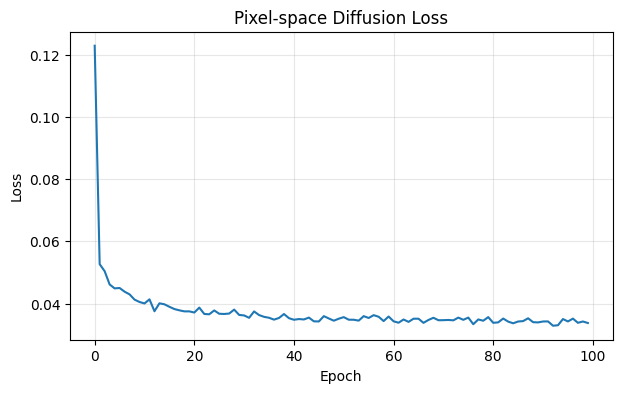

In [27]:
pixel_diffusion = GaussianDiffusion(num_timesteps=1000, device=device)
pixel_model = PixelUNet(in_channels=3, model_channels=128).to(device)



pixel_diffusion_100 = GaussianDiffusion(num_timesteps=100, device=device)
pixel_model_100 = PixelUNet(in_channels=3, model_channels=128).to(device)


optimizer = torch.optim.Adam(pixel_model_100.parameters(), lr=2e-4)

epochs = 100
#pixel_history = train_diffusion(pixel_model, train_loader_from_csv, pixel_diffusion, epochs=epochs, lr=2e-4)

pixel_history = fit_or_load_model(
    model=pixel_model,
    run_name='artbench_diffusion_pixel',
    train_fn = train_diffusion,
    load_if_available=USE_SAVED_MODELS_IF_AVAILABLE,
    loader=train_loader_from_csv,
    schedule=pixel_diffusion,
    epochs=epochs,
    lr=2e-4,
)   


if pixel_diffusion is None or pixel_model is None or optimizer is None or pixel_history is None:
    raise NotImplementedError('Set up and train the pixel-space diffusion model.')

plot_curve(pixel_history, title='Pixel-space Diffusion Loss')

Generate ArtBench samples from the trained diffusion model.

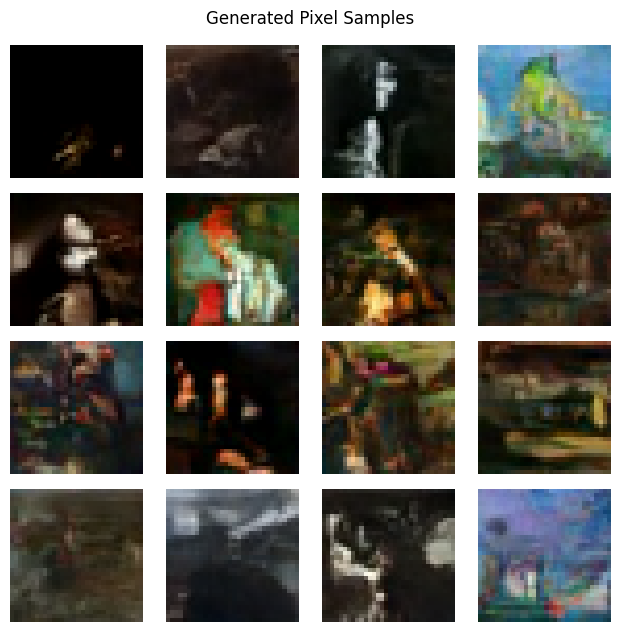

In [67]:
sampled = pixel_diffusion.p_sample_loop(pixel_model, shape=(16, 3, 32, 32))
# TODO END

if sampled is None:
    raise NotImplementedError('Generate pixel-space samples with p_sample_loop(...).')

show_image_grid(sampled, channels=3, title='Generated Pixel Samples', n_show=16)

## Evalution

### FID

In [28]:
def frechet_distance(mu_r, sigma_r, mu_g, sigma_g, eps=1e-6):
    # TODO START
    # 1) Convert inputs to float64 numpy arrays.
    mu_r = np.array(mu_r, dtype=np.float64)
    mu_g = np.array(mu_g, dtype=np.float64)
    
    # 2) Compute diff = mu_r - mu_g.
    diff = mu_r - mu_g
    
    # 3) Add eps * I for numerical stability.
    cov_r = sigma_r + eps * np.eye(sigma_r.shape[0])
    cov_g = sigma_g + eps * np.eye(sigma_g.shape[0])

    # 4) Compute the matrix square root of (Sigma_r + eps I)(Sigma_g + eps I).
    covmean, _ = linalg.sqrtm(cov_r @ cov_g, disp=False)
    
    # 5) If the result is complex, keep only the real part.
    if np.iscomplexobj(covmean):
        covmean = covmean.real

    # 6) Return the final FID scalar as a Python float.
    fid = diff.dot(diff) + np.trace(cov_r + cov_g - 2*covmean)
    return float(fid)
   
    # TODO END


### KID

In [29]:
def polynomial_kernel(x, y):
    d = x.shape[1]
    return ((x @ y.T) / d + 1.0) ** 3


def kid_score(features_real, features_fake, seed, subset_size=100, num_subsets=50):
    x = np.asarray(features_real, dtype=np.float64)
    y = np.asarray(features_fake, dtype=np.float64)
    m = min(len(x), len(y), subset_size)
    if m < 2:
        raise ValueError('Need at least 2 samples per set to compute KID.')

    rng = np.random.default_rng(seed)
    estimates = []
    for _ in range(num_subsets):
        x_idx = rng.choice(len(x), size=m, replace=False)
        y_idx = rng.choice(len(y), size=m, replace=False)
        x_sub = x[x_idx]
        y_sub = y[y_idx]

        k_xx = polynomial_kernel(x_sub, x_sub)
        k_yy = polynomial_kernel(y_sub, y_sub)
        k_xy = polynomial_kernel(x_sub, y_sub)

        mean_xx = (k_xx.sum() - np.trace(k_xx)) / (m * (m - 1))
        mean_yy = (k_yy.sum() - np.trace(k_yy)) / (m * (m - 1))
        mean_xy = k_xy.mean()
        estimates.append(mean_xx + mean_yy - 2.0 * mean_xy)

    return float(np.mean(estimates)), float(np.std(estimates))


In [30]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

def get_real_samples(n_samples=5000):
    real_imgs = []
    count = 0
    # Usamos o loader de teste para garantir que comparamos com dados reais
    for x, _, _ in test_loader_from_csv:
        real_imgs.append(x)
        count += x.size(0)
        if count >= n_samples:
            break
    # Junta tudo num tensor e corta exatamente em 5000
    return torch.cat(real_imgs, dim=0)[:n_samples].to(device)

def prepare_images_for_inception(images, device):
    if images.ndim == 3:
        images = images.unsqueeze(0)
    images = images.to(device=device, dtype=torch.float32)

    # converter de [-1,1] para [0,1]
    images = (images + 1) / 2

    if images.shape[1] == 1:
        images = images.repeat(1, 3, 1, 1)
    images = images.clamp(0, 1)
    images = F.interpolate(images, size=(299, 299), mode='bilinear', align_corners=False)

    mean = torch.tensor(IMAGENET_MEAN, device=device).view(1, 3, 1, 1)
    std = torch.tensor(IMAGENET_STD, device=device).view(1, 3, 1, 1)
    return (images - mean) / std



@torch.no_grad()
def extract_inception_features(images, model, batch_size=32, device=None):
    if device is None:
        device = next(model.parameters()).device
    features = []
    for start in range(0, len(images), batch_size):
        batch = prepare_images_for_inception(images[start:start + batch_size], device=device)
        feats = model(batch)
        if isinstance(feats, tuple):
            feats = feats[0]
        features.append(feats.detach().cpu())
    return torch.cat(features, dim=0)


def feature_statistics(features):
    features = np.asarray(features, dtype=np.float64)
    mu = features.mean(axis=0)
    sigma = np.cov(features, rowvar=False)
    return mu, sigma


def build_inception_feature_extractor(device=None):
    if device is None:
        device = get_device()
    model = inception_v3(weights=Inception_V3_Weights.DEFAULT, transform_input=False)
    model.fc = nn.Identity()
    model.eval()
    return model.to(device)



feature_extractor = build_inception_feature_extractor(device=device)



In [31]:
def evaluate_model(generate_fn, n_samples=5000, n_repetitions=10, batch_size=32, device=device):

    all_fid = []
    all_kid_mean = []
    all_kid_std = []

    real_images = get_real_samples(n_samples)
    feat_real = extract_inception_features(
        real_images, feature_extractor,
        batch_size=batch_size, device=device
    )
    feat_real_np = feat_real.numpy()
    mu_r, sigma_r = feature_statistics(feat_real_np)

    for seed in range(n_repetitions):
        torch.manual_seed(seed)
        np.random.seed(seed)

        # 1. Gerar imagens falsas
        fake_images = generate_fn(n_samples, device)

        # 2. Extrair features falsas
        feat_fake = extract_inception_features(
            fake_images, feature_extractor,
            batch_size=batch_size, device=device
        )
        feat_fake_np = feat_fake.numpy()

        # 3. FID
        mu_g, sigma_g = feature_statistics(feat_fake_np)
        fid = frechet_distance(mu_r, sigma_r, mu_g, sigma_g)
        all_fid.append(fid)

        # 4. KID
        kid_mean, kid_std = kid_score(feat_real_np, feat_fake_np, seed=seed)
        all_kid_mean.append(kid_mean)
        all_kid_std.append(kid_std)

        print(f"\n[RESULTADOS SEED {seed}]")
        print(f"   > FID: {fid:.4f}")
        print(f"   > KID: {kid_mean:.4f} ± {kid_std:.4f}")
        print("-" * 40, flush=True)

    # 5. Resultados Finais
    results = {
        "FID_mean": float(np.mean(all_fid)),
        "FID_std": float(np.std(all_fid)),
        "KID_mean": float(np.mean(all_kid_mean)),
        "KID_std": float(np.mean(all_kid_std)),
    }
    return results




# Função de geração para o VAE
def generate_vae(n_samples, device):
    vae.eval()
    with torch.no_grad():
        z = torch.randn(n_samples, vae.latent_dim).to(device)
        return vae.decode(z)

# Função de geração para o DCGAN
def generate_dcgan(n_samples, device):
    artbench_gen_infer.eval()
    with torch.no_grad():
        z = torch.randn(n_samples, 128, 1, 1).to(device)  # ajusta 128 se necessário
        return artbench_gen_infer(z)

# Função de geração para o Diffusion
def generate_diffusion(n_samples, device, batch_size=32):
    pixel_model_100.eval()
    all_samples = []
    
    # Divide os 5000 em pedaços menores
    for i in range(0, n_samples, batch_size):
        current_batch = min(batch_size, n_samples - i)
        print(f"Generating batch: {i}/{n_samples}...")
        
        with torch.no_grad():
            # Gera apenas um pequeno grupo de cada vez
            samples = pixel_diffusion_100.p_sample_loop(
                pixel_model_100, 
                shape=(current_batch, 3, 32, 32)
            )
            
            # MUITO IMPORTANTE: Move para a CPU e converte para float16 ou uint8 
            # para não estoirar a memória RAM enquanto acumulas
            all_samples.append(samples.cpu())
            
        # Limpa o lixo da memória da GPU após cada batch
        torch.cuda.empty_cache()

    # Junta tudo no final e devolve
    return torch.cat(all_samples, dim=0).to(device)

## 1. VAE Evaluation 20% (latent_dim =128, beta=0.5, epochs=100) 

In [42]:
results_vae = evaluate_model(generate_vae, n_samples=5000, n_repetitions=10, batch_size=32, device=device)
print("VAE:", results_vae)

C:\Users\ASUSR7\AppData\Local\Temp\ipykernel_54968\764392690.py:15: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = linalg.sqrtm(cov_r @ cov_g, disp=False)


VAE: {'FID_mean': 128.86030161464694, 'FID_std': 0.3829828736924987, 'KID_mean': 0.11577913778732045, 'KID_std': 0.006739003714576396}


## 2.DCGAN Evaluation 20% (latent_dim=128, epochs=100)

In [43]:
results_dcgan = evaluate_model(generate_dcgan, n_samples=5000, n_repetitions=10, batch_size=32, device=device)
print("DCGAN:", results_dcgan)

C:\Users\ASUSR7\AppData\Local\Temp\ipykernel_54968\764392690.py:15: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = linalg.sqrtm(cov_r @ cov_g, disp=False)


DCGAN: {'FID_mean': 52.328909894238336, 'FID_std': 0.3758438466750746, 'KID_mean': 0.03264371435540078, 'KID_std': 0.004950463616795581}


## 3.Pixel Diffusion Model 20%(timesteps=1000,model_channels=128, epochs=100, linear noise schedule)

In [ ]:
results_pixel_diffusion = evaluate_model(generate_diffusion, n_samples=5000, n_repetitions=10, batch_size=32, device=device)
print("Pixel Diffusion:", results_pixel_diffusion)

Generating batch: 0/5000...
Generating batch: 32/5000...
Generating batch: 64/5000...
Generating batch: 96/5000...
Generating batch: 128/5000...
Generating batch: 160/5000...
Generating batch: 192/5000...
Generating batch: 224/5000...
Generating batch: 256/5000...
Generating batch: 288/5000...
Generating batch: 320/5000...
Generating batch: 352/5000...
Generating batch: 384/5000...
Generating batch: 416/5000...
Generating batch: 448/5000...
Generating batch: 480/5000...
Generating batch: 512/5000...
Generating batch: 544/5000...
Generating batch: 576/5000...
Generating batch: 608/5000...
Generating batch: 640/5000...
Generating batch: 672/5000...
Generating batch: 704/5000...
Generating batch: 736/5000...
Generating batch: 768/5000...
Generating batch: 800/5000...
Generating batch: 832/5000...
Generating batch: 864/5000...
Generating batch: 896/5000...
Generating batch: 928/5000...
Generating batch: 960/5000...
Generating batch: 992/5000...
Generating batch: 1024/5000...
Generating bat

C:\Users\ASUSR7\AppData\Local\Temp\ipykernel_37004\764392690.py:15: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = linalg.sqrtm(cov_r @ cov_g, disp=False)



[RESULTADOS SEED 2]
   > FID: 123.9466
   > KID: 0.1122 ± 0.0086
----------------------------------------
Generating batch: 0/5000...
Generating batch: 32/5000...
Generating batch: 64/5000...
Generating batch: 96/5000...
Generating batch: 128/5000...
Generating batch: 160/5000...
Generating batch: 192/5000...
Generating batch: 224/5000...
Generating batch: 256/5000...
Generating batch: 288/5000...
Generating batch: 320/5000...
Generating batch: 352/5000...
Generating batch: 384/5000...
Generating batch: 416/5000...
Generating batch: 448/5000...
Generating batch: 480/5000...
Generating batch: 512/5000...
Generating batch: 544/5000...
Generating batch: 576/5000...
Generating batch: 608/5000...
Generating batch: 640/5000...
Generating batch: 672/5000...
Generating batch: 704/5000...
Generating batch: 736/5000...
Generating batch: 768/5000...
Generating batch: 800/5000...
Generating batch: 832/5000...
Generating batch: 864/5000...
Generating batch: 896/5000...
Generating batch: 928/5000..

## Retrain on full 50K dataset

## VAE (latent_dim =128, beta=0.5, epochs=100) 
## DCGAN (latent_dim=128, epochs=100)

Fila de espera iniciada em: 23:12:34

[23:12:34] INICIANDO: VAE (50K)
Loaded artbench_vae_final_50k model from artifacts\models\artbench_vae_final_50k.pt
[ArtBench VAE 50k] final train total: 137.2223
[ArtBench VAE 50k] final train recon: 90.8482
[ArtBench VAE 50k] final train KL: 92.7481
[ArtBench VAE 50k] test metrics: {'loss': 136.43037913818358, 'recon_bce': 90.11824907226563, 'kl': 92.6242607421875, 'mse': 0.0293353675365448, 'mae': 0.12570314540863037}


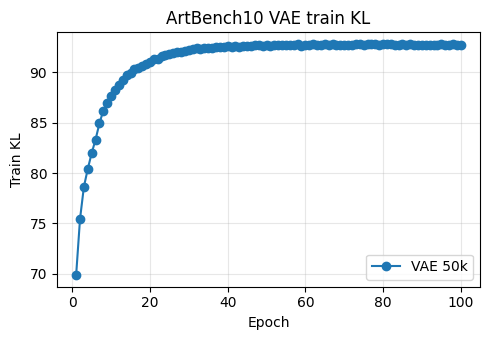

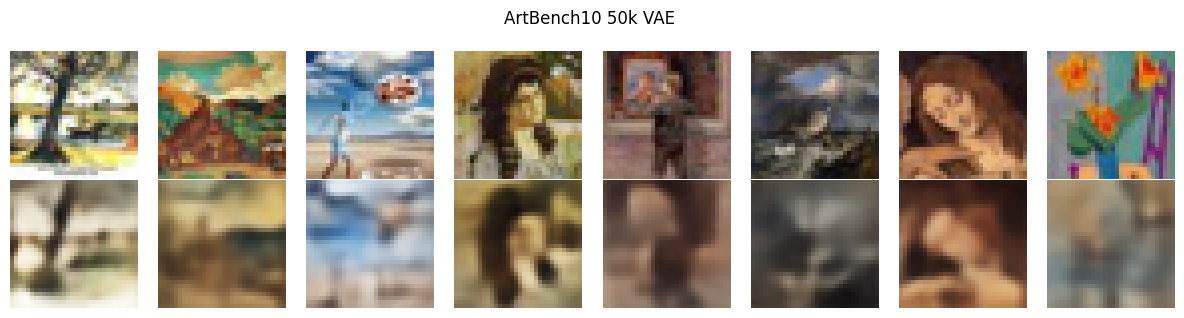

In [21]:
print(f"Fila de espera iniciada em: {datetime.now().strftime('%H:%M:%S')}")

################################################################################
# 1. TREINO FINAL DO VAE (50K)
################################################################################
print("\n" + "="*50)
print(f"[{datetime.now().strftime('%H:%M:%S')}] INICIANDO: VAE (50K)")
print("="*50)


vae_50k = ConvVAE(latent_dim=128).to(device)
opt_vae_50k = torch.optim.Adam(vae_50k.parameters(), lr=1e-3)
EPOCHS_VAE = 100
BETA_VAE = 0.5
# TODO END
hist_vae_50k = fit_or_load_model(
    model=vae_50k,
    run_name='artbench_vae_final_50k',
    train_fn=train_vae,
    load_if_available=USE_SAVED_MODELS_IF_AVAILABLE,
    loader=train_loader,   # train loader do subset de 50k
    optimizer=opt_vae_50k,
    epochs=EPOCHS_VAE,
    beta=BETA_VAE,
)
metrics_vae_50k = evaluate_vae(vae_50k, test_loader_from_csv, beta=BETA_VAE)


report_vae_metrics('ArtBench VAE 50k', hist_vae_50k, metrics_vae_50k)

plot_epoch_metric({'VAE 50k': hist_vae_50k}, 'train_kl', 'ArtBench10 VAE train KL', 'Train KL')

show_reconstructions_vae(vae_50k, test_loader_from_csv, title='ArtBench10 50k VAE ')



In [ ]:
# Configurações DCGAN
artbench_ckpt_50k = Path('artifacts/models/artbench_dcgan_final_50k.pt')

# Inicializar modelos do zero
artbench_generator_50k = DCGenerator(latent_dim=128, image_channels=3).to(device)
artbench_discriminator_50k = DCDiscriminator(image_channels=3).to(device)

artbench_generator_50k.apply(init_dcgan_weights)
artbench_discriminator_50k.apply(init_dcgan_weights)

# Treinar GAN
artbench_history_50k = train_gan(
    generator=artbench_generator_50k,
    discriminator=artbench_discriminator_50k,
    loader=train_loader,      # Dataset de 50.000 imagens
    latent_dim=128,
    epochs=100,
    lr=2e-4,
)

# Salvar Checkpoint da GAN
save_checkpoint(
    generator=artbench_generator_50k,
    discriminator=artbench_discriminator_50k,
    history=artbench_history_50k,
    checkpoint_path=artbench_ckpt_50k,
    latent_dim=128,
    channels=3,
    image_size=32,
)

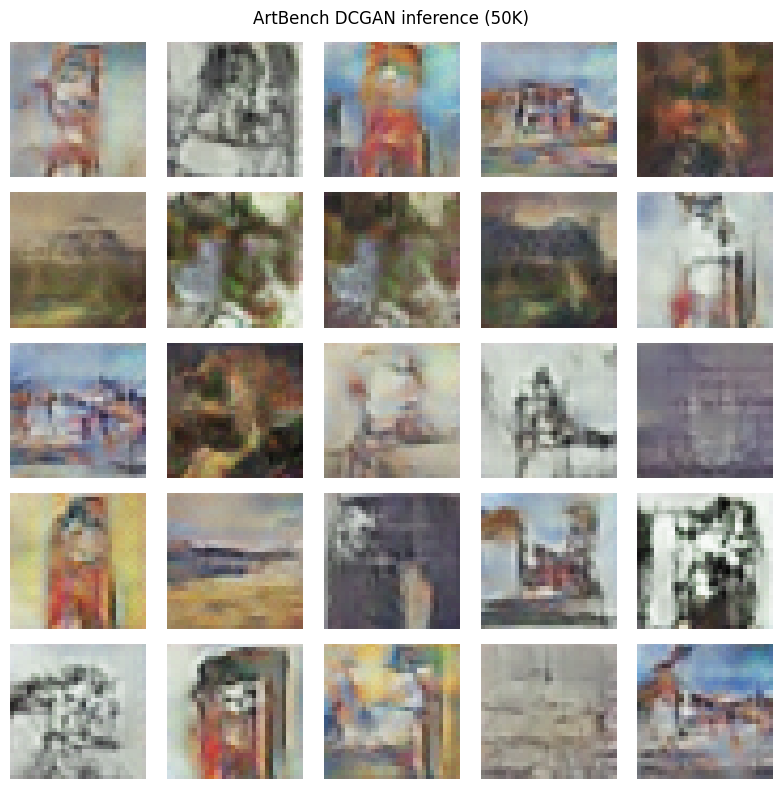

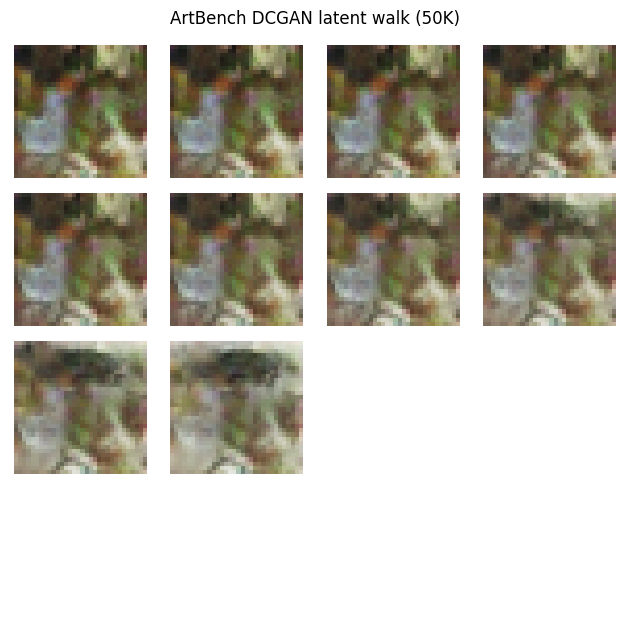

NameError: name 'artbench_history_50k' is not defined

In [33]:
artbench_ckpt_50k = Path('artifacts/models/artbench_dcgan_final_50k.pt')

artbench_gen_infer_50k, artbench_cfg_50k, _ = load_dcgan_generator_for_inference(artbench_ckpt_50k)


if artbench_gen_infer_50k is None or artbench_cfg_50k is None:
    raise NotImplementedError('Load ArtBench DCGAN checkpoint for inference.')

# TODO START
# Call run_inference(...) and latent_walk(...)
run_inference(
    generator=artbench_gen_infer_50k,
    latent_dim=artbench_cfg_50k['latent_dim'],
    channels=artbench_cfg_50k['channels'],
    n_samples=25,
    seed=123,
    title='ArtBench DCGAN inference (50K)',
)

latent_walk(
    generator=artbench_gen_infer_50k,
    latent_dim=artbench_cfg_50k['latent_dim'],
    channels=artbench_cfg_50k['channels'],
    steps=10,
    title='ArtBench DCGAN latent walk (50K)',
)

plot_gan_losses(artbench_history_50k, title='ArtBench 50K DCGAN losses')

## Diffusion (timesteps=100, epochs=100)

Loaded artbench_diffusion_pixel_final_50k model from artifacts\models\artbench_diffusion_pixel_final_50k.pt


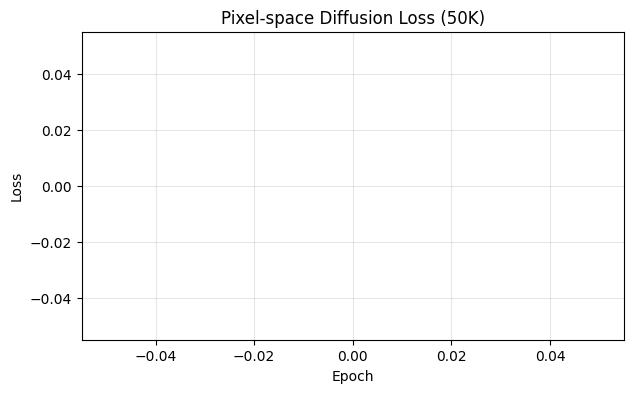

In [29]:
pixel_diffusion_50k = GaussianDiffusion(num_timesteps=1000, device=device)
pixel_model_50k = PixelUNet(in_channels=3, model_channels=128).to(device)

optimizer_50k = torch.optim.Adam(pixel_model_50k.parameters(), lr=2e-4)

epochs = 100

pixel_history_50k = fit_or_load_model(
    model=pixel_model_50k,
    run_name='artbench_diffusion_pixel_final_50k',
    train_fn = train_diffusion,
    load_if_available=USE_SAVED_MODELS_IF_AVAILABLE,
    loader=train_loader,   # train loader do subset de 50k
    schedule=pixel_diffusion_50k,
    epochs=epochs,
    lr=2e-4,
)   


if pixel_diffusion_50k is None or pixel_model_50k is None or optimizer_50k is None or pixel_history_50k is None:
    raise NotImplementedError('Set up and train the pixel-space diffusion model.')

plot_curve(pixel_history_50k, title='Pixel-space Diffusion Loss (50K)')

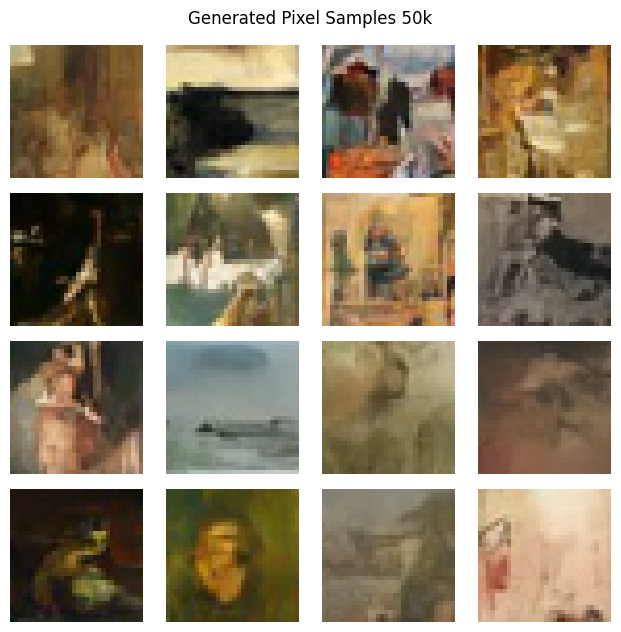

In [23]:
sampled_50k = pixel_diffusion_50k.p_sample_loop(pixel_model_50k, shape=(16, 3, 32, 32))
# TODO END

if sampled_50k is None:
    raise NotImplementedError('Generate pixel-space samples with p_sample_loop(...).')

show_image_grid(sampled_50k, channels=3, title='Generated Pixel Samples 50k', n_show=16)

In [35]:
# Função de geração para o VAE
def generate_vae_50k(n_samples, device):
    vae_50k.eval()
    with torch.no_grad():
        z = torch.randn(n_samples, vae_50k.latent_dim).to(device)
        return vae_50k.decode(z)

# Função de geração para o DCGAN
def generate_dcgan_50k(n_samples, device):
    artbench_gen_infer_50k.eval()
    with torch.no_grad():
        z = torch.randn(n_samples, 128, 1, 1).to(device) 
        return artbench_gen_infer_50k(z)

# Função de geração para o Diffusion
def generate_diffusion_50k(n_samples, device, batch_size=32):
    pixel_model_50k.eval()
    all_samples = []
    
    # Divide os 5000 em pedaços menores
    for i in range(0, n_samples, batch_size):
        current_batch = min(batch_size, n_samples - i)
        print(f"Generating batch: {i}/{n_samples}...")
        
        with torch.no_grad():
            # Gera apenas um pequeno grupo de cada vez
            samples = pixel_diffusion_50k.p_sample_loop(
                pixel_model_50k, 
                shape=(current_batch, 3, 32, 32)
            )
            
            # MUITO IMPORTANTE: Move para a CPU e converte para float16 ou uint8 
            # para não estoirar a memória RAM enquanto acumulas
            all_samples.append(samples.cpu())
            
        # Limpa o lixo da memória da GPU após cada batch
        torch.cuda.empty_cache()

    # Junta tudo no final e devolve
    return torch.cat(all_samples, dim=0).to(device)

## Evaluation VAE 50k

In [59]:
results_vae_50k = evaluate_model(generate_vae_50k, n_samples=5000, n_repetitions=10, batch_size=32, device=device)
print("VAE 50k:", results_vae_50k)

C:\Users\ASUSR7\AppData\Local\Temp\ipykernel_37004\764392690.py:15: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = linalg.sqrtm(cov_r @ cov_g, disp=False)



[RESULTADOS SEED 0]
   > FID: 129.9117
   > KID: 0.1190 ± 0.0069
----------------------------------------

[RESULTADOS SEED 1]
   > FID: 130.2723
   > KID: 0.1192 ± 0.0070
----------------------------------------

[RESULTADOS SEED 2]
   > FID: 130.2522
   > KID: 0.1174 ± 0.0068
----------------------------------------

[RESULTADOS SEED 3]
   > FID: 130.8581
   > KID: 0.1209 ± 0.0075
----------------------------------------

[RESULTADOS SEED 4]
   > FID: 131.0296
   > KID: 0.1177 ± 0.0069
----------------------------------------

[RESULTADOS SEED 5]
   > FID: 130.2515
   > KID: 0.1183 ± 0.0074
----------------------------------------

[RESULTADOS SEED 6]
   > FID: 130.0701
   > KID: 0.1167 ± 0.0072
----------------------------------------

[RESULTADOS SEED 7]
   > FID: 130.6723
   > KID: 0.1173 ± 0.0078
----------------------------------------

[RESULTADOS SEED 8]
   > FID: 129.7610
   > KID: 0.1177 ± 0.0070
----------------------------------------

[RESULTADOS SEED 9]
   > FID: 130.92

## Evaluation DCGAN 50k

In [65]:
results_dcgan_50k = evaluate_model(generate_dcgan_50k, n_samples=5000, n_repetitions=10, batch_size=32, device=device)
print("DCGAN 50k:", results_dcgan_50k)

C:\Users\ASUSR7\AppData\Local\Temp\ipykernel_37004\764392690.py:15: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = linalg.sqrtm(cov_r @ cov_g, disp=False)



[RESULTADOS SEED 0]
   > FID: 92.6170
   > KID: 0.0599 ± 0.0081
----------------------------------------

[RESULTADOS SEED 1]
   > FID: 90.9578
   > KID: 0.0584 ± 0.0079
----------------------------------------

[RESULTADOS SEED 2]
   > FID: 93.2724
   > KID: 0.0594 ± 0.0082
----------------------------------------

[RESULTADOS SEED 3]
   > FID: 91.5999
   > KID: 0.0595 ± 0.0091
----------------------------------------

[RESULTADOS SEED 4]
   > FID: 92.3509
   > KID: 0.0587 ± 0.0073
----------------------------------------

[RESULTADOS SEED 5]
   > FID: 90.5843
   > KID: 0.0578 ± 0.0075
----------------------------------------

[RESULTADOS SEED 6]
   > FID: 93.3461
   > KID: 0.0614 ± 0.0105
----------------------------------------

[RESULTADOS SEED 7]
   > FID: 93.5536
   > KID: 0.0604 ± 0.0087
----------------------------------------

[RESULTADOS SEED 8]
   > FID: 93.1332
   > KID: 0.0610 ± 0.0094
----------------------------------------

[RESULTADOS SEED 9]
   > FID: 92.4342
   > KI

## Evaluation Diffusion 50k

In [ ]:
results_diffusion_50k = evaluate_model(generate_diffusion_50k, n_samples=5000, n_repetitions=10, batch_size=32, device=device)
print("Diffusion 50k:", results_diffusion_50k)

Generating batch: 0/5000...
Generating batch: 32/5000...
Generating batch: 64/5000...
Generating batch: 96/5000...
Generating batch: 128/5000...
Generating batch: 160/5000...
Generating batch: 192/5000...
Generating batch: 224/5000...
Generating batch: 256/5000...
Generating batch: 288/5000...
Generating batch: 320/5000...
Generating batch: 352/5000...
Generating batch: 384/5000...
Generating batch: 416/5000...
Generating batch: 448/5000...
Generating batch: 480/5000...
Generating batch: 512/5000...
Generating batch: 544/5000...
Generating batch: 576/5000...
Generating batch: 608/5000...
Generating batch: 640/5000...
Generating batch: 672/5000...
Generating batch: 704/5000...
Generating batch: 736/5000...
Generating batch: 768/5000...
Generating batch: 800/5000...
Generating batch: 832/5000...
Generating batch: 864/5000...
Generating batch: 896/5000...
Generating batch: 928/5000...
Generating batch: 960/5000...
Generating batch: 992/5000...
Generating batch: 1024/5000...
Generating bat

C:\Users\ASUSR7\AppData\Local\Temp\ipykernel_28956\764392690.py:15: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = linalg.sqrtm(cov_r @ cov_g, disp=False)



[RESULTADOS SEED 0]
   > FID: 39.2241
   > KID: 0.0248 ± 0.0050
----------------------------------------
Generating batch: 0/5000...
Generating batch: 32/5000...
Generating batch: 64/5000...
Generating batch: 96/5000...
Generating batch: 128/5000...
Generating batch: 160/5000...
Generating batch: 192/5000...
Generating batch: 224/5000...
Generating batch: 256/5000...
Generating batch: 288/5000...
Generating batch: 320/5000...
Generating batch: 352/5000...
Generating batch: 384/5000...
Generating batch: 416/5000...
Generating batch: 448/5000...
Generating batch: 480/5000...
Generating batch: 512/5000...
Generating batch: 544/5000...
Generating batch: 576/5000...
Generating batch: 608/5000...
Generating batch: 640/5000...
Generating batch: 672/5000...
Generating batch: 704/5000...
Generating batch: 736/5000...
Generating batch: 768/5000...
Generating batch: 800/5000...
Generating batch: 832/5000...
Generating batch: 864/5000...
Generating batch: 896/5000...
Generating batch: 928/5000...